In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import sklearn
from sklearn.model_selection import train_test_split

# 0. Dataset 전처리

In [2]:
# Load the Titanic dataset
df = pd.read_csv("https://raw.githubusercontent.com/StillWork/data/master/titanic_train.csv")

# Preprocess the data
df = df.dropna()

df.head() # passengerid 는 필요가 없음

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


In [3]:
X = df[["Pclass", "Sex", "Age", "Fare"]]
y = df["Survived"]

# Convert categorical features to one-hot encoding
X = pd.get_dummies(X, columns=["Sex"], dtype='int').values
y = y.values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
print(X_train[:5])
print(y_train[:5])

[[ 1.     55.     30.5     0.      1.    ]
 [ 1.     16.     57.9792  1.      0.    ]
 [ 3.      4.     16.7     1.      0.    ]
 [ 1.     31.     52.      0.      1.    ]
 [ 1.     44.     57.9792  1.      0.    ]]
[0 1 1 0 1]


# 1. Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression # linear 모델 안에 있음

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

LogisticRegression()

# 2. Neural Network with FC Layers

In [6]:
# Define torch Dataset - 데이터셋 먼저 만들기
class MyTitanicDataset(Dataset): # 커스텀 데이터셋(ㅑ
    def __init__(self, x_data, y_data):
        self.x_data = torch.tensor(x_data, dtype=torch.float32)
        self.y_data = torch.tensor(y_data, dtype=torch.long)

    def __getitem__(self, index): # 해당하는 인덱스 위치에 있는 값 호출하는 용도
        return self.x_data[index], self.y_data[index]

    def __len__(self): # 전체 길이
        return self.x_data.shape[0]

dataset = MyTitanicDataset(X_train, y_train)

In [7]:
# Define the neural network architecture
class MyClassificationModel(nn.Module):
    def __init__(self):
        super(MyClassificationModel, self).__init__()
        self.fc1 = nn.Linear(5, 10)
        self.fc2 = nn.Linear(10, 5)
        self.fc3 = nn.Linear(5, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 모델 선언
model = MyClassificationModel()

In [8]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create a data loader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)

In [9]:
from tqdm import tqdm

# Train the model
losses = []

for epoch in tqdm(range(100)):
    for i, (x, y) in enumerate(dataloader):
        # Forward pass
        y_pred = model(x)
        loss = criterion(y_pred, y)
        losses.append(loss.item())

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print training progress
        if i % 10 == 0:
            print(f"Epoch: {epoch + 1}, Batch: {i}, Loss: {loss.item():.4f}")

  8%|▊         | 8/100 [00:00<00:02, 37.11it/s]

Epoch: 1, Batch: 0, Loss: 0.3973
Epoch: 1, Batch: 10, Loss: 0.4057
Epoch: 2, Batch: 0, Loss: 0.8183
Epoch: 2, Batch: 10, Loss: 0.5990
Epoch: 3, Batch: 0, Loss: 0.5267
Epoch: 3, Batch: 10, Loss: 0.6735
Epoch: 4, Batch: 0, Loss: 0.7667
Epoch: 4, Batch: 10, Loss: 0.9380
Epoch: 5, Batch: 0, Loss: 0.6010
Epoch: 5, Batch: 10, Loss: 0.6115
Epoch: 6, Batch: 0, Loss: 0.6479
Epoch: 6, Batch: 10, Loss: 0.7415
Epoch: 7, Batch: 0, Loss: 0.5860
Epoch: 7, Batch: 10, Loss: 0.6112
Epoch: 8, Batch: 0, Loss: 0.8705
Epoch: 8, Batch: 10, Loss: 0.4936
Epoch: 9, Batch: 0, Loss: 0.7637
Epoch: 9, Batch: 10, Loss: 0.7705
Epoch: 10, Batch: 0, Loss: 0.6306
Epoch: 10, Batch: 10, Loss: 0.5704
Epoch: 11, Batch: 0, Loss: 0.6378
Epoch: 11, Batch: 10, Loss: 0.5989
Epoch: 12, Batch: 0, Loss: 0.6900
Epoch: 12, Batch: 10, Loss: 0.6496
Epoch: 13, Batch: 0, Loss: 0.5466


 21%|██        | 21/100 [00:00<00:01, 52.71it/s]

Epoch: 13, Batch: 10, Loss: 0.6125
Epoch: 14, Batch: 0, Loss: 0.4945
Epoch: 14, Batch: 10, Loss: 0.6270
Epoch: 15, Batch: 0, Loss: 0.6910
Epoch: 15, Batch: 10, Loss: 0.6310
Epoch: 16, Batch: 0, Loss: 0.6221
Epoch: 16, Batch: 10, Loss: 0.6388
Epoch: 17, Batch: 0, Loss: 0.7823
Epoch: 17, Batch: 10, Loss: 0.6512
Epoch: 18, Batch: 0, Loss: 0.7753
Epoch: 18, Batch: 10, Loss: 0.5922
Epoch: 19, Batch: 0, Loss: 0.5515
Epoch: 19, Batch: 10, Loss: 0.3548
Epoch: 20, Batch: 0, Loss: 0.5333
Epoch: 20, Batch: 10, Loss: 0.6209
Epoch: 21, Batch: 0, Loss: 0.6491
Epoch: 21, Batch: 10, Loss: 0.6488
Epoch: 22, Batch: 0, Loss: 0.5810
Epoch: 22, Batch: 10, Loss: 0.4688
Epoch: 23, Batch: 0, Loss: 0.4816
Epoch: 23, Batch: 10, Loss: 0.4960
Epoch: 24, Batch: 0, Loss: 0.5480
Epoch: 24, Batch: 10, Loss: 0.5728
Epoch: 25, Batch: 0, Loss: 0.6819
Epoch: 25, Batch: 10, Loss: 0.5718
Epoch: 26, Batch: 0, Loss: 0.5569


 34%|███▍      | 34/100 [00:00<00:01, 57.17it/s]

...

Epoch: 63, Batch: 10, Loss: 0.5766
Epoch: 64, Batch: 0, Loss: 0.4902
Epoch: 64, Batch: 10, Loss: 0.6644
Epoch: 65, Batch: 0, Loss: 0.4073
Epoch: 65, Batch: 10, Loss: 0.5378
Epoch: 66, Batch: 0, Loss: 0.3918
Epoch: 66, Batch: 10, Loss: 0.4836
Epoch: 67, Batch: 0, Loss: 0.4836
Epoch: 67, Batch: 10, Loss: 0.5685
Epoch: 68, Batch: 0, Loss: 0.4067
Epoch: 68, Batch: 10, Loss: 0.4142
Epoch: 69, Batch: 0, Loss: 0.4454
Epoch: 69, Batch: 10, Loss: 0.3441
Epoch: 70, Batch: 0, Loss: 0.4853
Epoch: 70, Batch: 10, Loss: 0.2308
Epoch: 71, Batch: 0, Loss: 0.4419
Epoch: 71, Batch: 10, Loss: 0.3437
Epoch: 72, Batch: 0, Loss: 0.5011
Epoch: 72, Batch: 10, Loss: 0.4070
Epoch: 73, Batch: 0, Loss: 0.4603
Epoch: 73, Batch: 10, Loss: 0.3346
Epoch: 74, Batch: 0, Loss: 0.3788
Epoch: 74, Batch: 10, Loss: 0.3478
Epoch: 75, Batch: 0, Loss: 0.6601
Epoch: 75, Batch: 10, Loss: 0.4471
Epoch: 76, Batch: 0, Loss: 0.4178


 82%|████████▏ | 82/100 [00:01<00:00, 61.22it/s]

Epoch: 76, Batch: 10, Loss: 0.4434
Epoch: 77, Batch: 0, Loss: 0.5076
Epoch: 77, Batch: 10, Loss: 0.4572
Epoch: 78, Batch: 0, Loss: 0.3567
Epoch: 78, Batch: 10, Loss: 0.4603
Epoch: 79, Batch: 0, Loss: 0.7029
Epoch: 79, Batch: 10, Loss: 0.5365
Epoch: 80, Batch: 0, Loss: 0.7465
Epoch: 80, Batch: 10, Loss: 0.4079
Epoch: 81, Batch: 0, Loss: 0.4177
Epoch: 81, Batch: 10, Loss: 0.4944
Epoch: 82, Batch: 0, Loss: 0.5270
Epoch: 82, Batch: 10, Loss: 0.2569
Epoch: 83, Batch: 0, Loss: 0.5694
Epoch: 83, Batch: 10, Loss: 0.3612
Epoch: 84, Batch: 0, Loss: 0.3554
Epoch: 84, Batch: 10, Loss: 0.6001
Epoch: 85, Batch: 0, Loss: 0.3498
Epoch: 85, Batch: 10, Loss: 0.2966
Epoch: 86, Batch: 0, Loss: 0.4640
Epoch: 86, Batch: 10, Loss: 0.3712
Epoch: 87, Batch: 0, Loss: 0.3916
Epoch: 87, Batch: 10, Loss: 0.4824
Epoch: 88, Batch: 0, Loss: 0.4144
Epoch: 88, Batch: 10, Loss: 0.3389
Epoch: 89, Batch: 0, Loss: 0.5159


100%|██████████| 100/100 [00:01<00:00, 56.67it/s]

Epoch: 89, Batch: 10, Loss: 0.4338
Epoch: 90, Batch: 0, Loss: 0.2923
Epoch: 90, Batch: 10, Loss: 0.4185
Epoch: 91, Batch: 0, Loss: 0.2929
Epoch: 91, Batch: 10, Loss: 0.2862
Epoch: 92, Batch: 0, Loss: 0.2410
Epoch: 92, Batch: 10, Loss: 0.4175
Epoch: 93, Batch: 0, Loss: 0.4532
Epoch: 93, Batch: 10, Loss: 0.4301
Epoch: 94, Batch: 0, Loss: 0.3420
Epoch: 94, Batch: 10, Loss: 0.3165
Epoch: 95, Batch: 0, Loss: 0.5221
Epoch: 95, Batch: 10, Loss: 0.5010
Epoch: 96, Batch: 0, Loss: 0.6630
Epoch: 96, Batch: 10, Loss: 0.1645
Epoch: 97, Batch: 0, Loss: 0.2287
Epoch: 97, Batch: 10, Loss: 0.4148
Epoch: 98, Batch: 0, Loss: 0.2646
Epoch: 98, Batch: 10, Loss: 0.3782
Epoch: 99, Batch: 0, Loss: 0.4290
Epoch: 99, Batch: 10, Loss: 0.3962
Epoch: 100, Batch: 0, Loss: 0.2605
Epoch: 100, Batch: 10, Loss: 0.2636


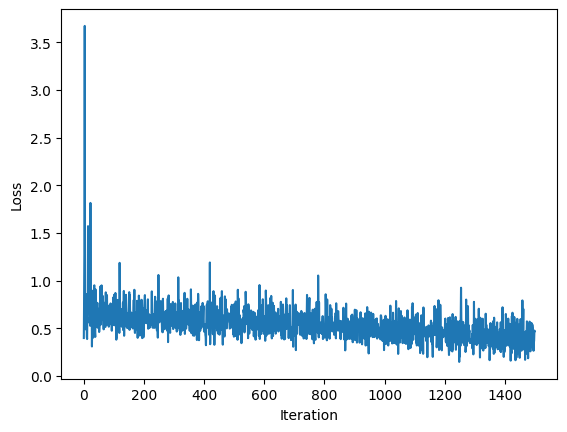

In [10]:
# Loss Graph 시각화
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# 3. 모델 평가

### Logistic Regression Model

In [11]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

y_pred = lr_model.predict(X_test)

print('Accuracy : ', accuracy_score(y_pred, y_test))
print('precision : ', precision_score(y_pred, y_test))
print('recall : ', recall_score(y_pred, y_test))
print('f1 : ', f1_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

Accuracy :  0.7297297297297297
precision :  0.84
recall :  0.7777777777777778
f1 :  0.8076923076923077
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.84      0.78      0.81        27

    accuracy                           0.73        37
   macro avg       0.67      0.69      0.68        37
weighted avg       0.75      0.73      0.74        37



### Neural Network

In [12]:
# Evaluate the network
nn_y_pred = []

with torch.no_grad(): # model.eval()
    for x, y in zip(X_test, y_test):
        outputs = model(torch.tensor([x], dtype=torch.float32))
        _, predicted = torch.max(outputs.data, 1)
        nn_y_pred.append(predicted.detach().cpu().item())


print('Accuracy : ', accuracy_score(nn_y_pred, y_test))
print('precision : ', precision_score(nn_y_pred, y_test))
print('recall : ', recall_score(nn_y_pred, y_test))
print('f1 : ', f1_score(nn_y_pred, y_test))
print(classification_report(nn_y_pred, y_test))

Accuracy :  0.7297297297297297
precision :  0.76
recall :  0.8260869565217391
f1 :  0.7916666666666666
              precision    recall  f1-score   support

           0       0.67      0.57      0.62        14
           1       0.76      0.83      0.79        23

    accuracy                           0.73        37
   macro avg       0.71      0.70      0.70        37
weighted avg       0.72      0.73      0.72        37



<ipython-input-12-14a770552cb5>:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  outputs = model(torch.tensor([x], dtype=torch.float32))
